# Bonus Problem — Parking Availability Prediction

## Problem Definition

A considerable portion of property advertisements has missing information for
`has_parking`.

The goal of this analysis is to investigate whether the availability of parking can
be predicted from other known characteristics of a property.

The problem is formulated as a supervised binary classification task:

- Target: `has_parking`
- Training data: advertisements with known parking information
- Prediction data: advertisements where `has_parking` is missing

If the model achieves acceptable performance on unseen labeled data, it can then be
used to estimate the missing parking information and enrich the dataset for future
recommendation systems.

## 1. Load Dataset and Inspect the Target

Before building a classification model, we first inspect the target variable to
understand:

- how much labeled data is available,
- how many values are missing,
- what values are used to represent parking availability,
- and whether the target classes are balanced.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/Divar.csv")

print("Dataset shape:", df.shape)

/tmp/ipykernel_15338/3553224081.py:7: DtypeWarning: Columns (11: rent_to_single, 27: floor, 29: total_floors_count, 53: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/Divar.csv")


Dataset shape: (1000000, 61)


In [6]:
print("has_parking dtype:", df["has_parking"].dtype)

print("\nValue counts:")
print(df["has_parking"].value_counts(dropna=False))

print("\nMissing percentage:")
print(
    round(df["has_parking"].isna().mean() * 100, 2),
    "%"
)

has_parking dtype: object

Value counts:
has_parking
True     552542
NaN      271844
False    175614
Name: count, dtype: int64

Missing percentage:
27.18 %


In [7]:
parking_counts = (
    df["has_parking"]
    .value_counts(dropna=False)
)

parking_counts

has_parking
True     552542
NaN      271844
False    175614
Name: count, dtype: int64

## 2. Candidate Feature Selection

The target variable is moderately imbalanced, with substantially more properties
having parking than not having parking.

Therefore, model performance should not be evaluated using accuracy alone.
Metrics such as Precision, Recall, F1-score, ROC-AUC, and the confusion matrix will
also be considered.

Next, candidate features are selected based on:

- relevance to parking availability,
- data availability,
- interpretability,
- and avoidance of target leakage.

In [8]:
candidate_features = [
    "city_slug",
    "cat2_slug",
    "cat3_slug",
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "has_elevator",
    "has_warehouse",
    "property_type",
    "price_value"
]

feature_audit = pd.DataFrame({
    "dtype": df[candidate_features].dtypes.astype(str),
    "missing_percent": (
        df[candidate_features].isna().mean() * 100
    ).round(2),
    "unique_count": (
        df[candidate_features].nunique(dropna=True)
    )
})

feature_audit.sort_values("missing_percent")

,dtype,missing_percent,unique_count
city_slug,str,0.00,421
cat2_slug,str,0.00,6
cat3_slug,str,0.00,16
building_size,float64,1.96,3572
rooms_count,str,15.41,6
construction_year,str,18.42,34
has_warehouse,object,27.18,2
price_value,float64,43.17,12943
has_elevator,object,45.83,2
floor,object,45.83,50


### 2.1 Feature Availability in the Prediction Population

A feature can be useful for training but still be unsuitable for the final prediction
task if it is mostly missing in the advertisements where `has_parking` is unknown.

Therefore, candidate features are evaluated separately for:

- labeled advertisements, where `has_parking` is known,
- unlabeled advertisements, where parking information must be predicted.

This helps ensure that the selected features will actually be available at inference time.

In [9]:
labeled_mask = df["has_parking"].notna()
unlabeled_mask = df["has_parking"].isna()

availability_comparison = pd.DataFrame({
    "missing_labeled_%": (
        df.loc[labeled_mask, candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    
    "missing_unlabeled_%": (
        df.loc[unlabeled_mask, candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

availability_comparison["difference_%"] = (
    availability_comparison["missing_unlabeled_%"]
    - availability_comparison["missing_labeled_%"]
).round(2)

availability_comparison.sort_values("missing_unlabeled_%")

,missing_labeled_%,missing_unlabeled_%,difference_%
city_slug,0.00,0.00,0.00
cat2_slug,0.00,0.00,0.00
cat3_slug,0.00,0.00,0.00
building_size,0.00,7.21,7.21
price_value,41.00,48.96,7.96
rooms_count,0.00,56.69,56.69
construction_year,0.00,67.75,67.75
property_type,96.88,98.39,1.51
total_floors_count,58.20,100.00,41.80
floor,25.60,100.00,74.40


### 2.2 Investigating Whether Missing Parking Values Are Structural

The missingness pattern suggests that `has_parking` may not be missing at random.

Several property-related features such as `has_warehouse`, `has_elevator`, and `floor`
are completely unavailable when `has_parking` is missing. This may indicate that
different advertisement categories use different input schemas.

Before treating missing parking values as unknown labels, we therefore investigate
how parking availability and missingness are distributed across property categories.

This step prevents the model from predicting parking for categories where the concept
may not be applicable or was never collected.

In [10]:
parking_by_cat3 = pd.crosstab(
    df["cat3_slug"],
    df["has_parking"].isna(),
    margins=True
)

parking_by_cat3.columns = [
    "parking_known",
    "parking_missing",
    "total"
]

parking_by_cat3["missing_%"] = (
    parking_by_cat3["parking_missing"]
    / parking_by_cat3["total"]
    * 100
).round(2)

parking_by_cat3.sort_values(
    "missing_%",
    ascending=False
)

,parking_known,parking_missing,total,missing_%
cat3_slug,,,,
industry-agriculture-business-rent,0,9155,9155,100.00
workspace,0,539,539,100.00
partnership,0,3622,3622,100.00
villa,0,12899,12899,100.00
suite-apartment,0,16465,16465,100.00
shop-sell,0,21855,21855,100.00
shop-rent,0,45993,45993,100.00
presell,0,15781,15781,100.00
plot-old,1,133569,133570,100.00


In [11]:
parking_target_by_cat3 = pd.crosstab(
    df["cat3_slug"],
    df["has_parking"],
    margins=True
)

parking_target_by_cat3

has_parking,False,True,All
cat3_slug,,,
apartment-rent,56237,155630,211867
apartment-sell,53034,250345,303379
house-villa-rent,29146,35521,64667
house-villa-sell,23326,98412,121738
industry-agriculture-business-sell,0,1,1
office-rent,11654,9694,21348
office-sell,2217,2938,5155
plot-old,0,1,1
All,175614,552542,728156


## Main Question

### Predicting parking availability for property categories where parking is an applicable and routinely collected attribute.


#

## 3. Define the Modeling Population

The previous analysis shows that missing parking values are highly structural.

For several property categories, parking information is almost never collected.
Therefore, predicting parking for those categories would not be statistically or
semantically justified.

The classification problem is consequently restricted to categories where parking
is a routinely collected and meaningful attribute:

- apartment-sell
- apartment-rent
- house-villa-sell
- house-villa-rent
- office-sell
- office-rent

The model will be trained and evaluated only on labeled observations from these
categories.

In [12]:
applicable_categories = [
    "apartment-sell",
    "apartment-rent",
    "house-villa-sell",
    "house-villa-rent",
    "office-sell",
    "office-rent"
]

parking_df = df[
    df["cat3_slug"].isin(applicable_categories)
].copy()

print("Applicable population:", len(parking_df))

print("\nParking target:")
print(parking_df["has_parking"].value_counts(dropna=False))

print(
    "\nMissing parking values:",
    parking_df["has_parking"].isna().sum()
)

Applicable population: 728269

Parking target:
has_parking
True     552540
False    175614
NaN         115
Name: count, dtype: int64

Missing parking values: 115


### 3.1 Feature Availability in the Final Modeling Population

After restricting the analysis to relevant property categories, feature availability
is inspected again.

This is necessary because the missingness patterns in the full dataset were strongly
affected by categories for which parking was not applicable.

In [13]:
model_candidate_features = [
    "city_slug",
    "cat2_slug",
    "cat3_slug",
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "has_elevator",
    "has_warehouse",
    "price_value"
]

labeled_parking = parking_df[
    parking_df["has_parking"].notna()
].copy()

unlabeled_parking = parking_df[
    parking_df["has_parking"].isna()
].copy()

final_feature_audit = pd.DataFrame({
    "missing_labeled_%": (
        labeled_parking[model_candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    "missing_unlabeled_%": (
        unlabeled_parking[model_candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    "unique_count": (
        labeled_parking[model_candidate_features]
        .nunique(dropna=True)
    )
})

final_feature_audit.sort_values("missing_labeled_%")

,missing_labeled_%,missing_unlabeled_%,unique_count
city_slug,0.00,0.00,419
cat2_slug,0.00,0.00,4
cat3_slug,0.00,0.00,6
building_size,0.00,99.13,1364
rooms_count,0.00,100.00,6
construction_year,0.00,99.13,34
has_warehouse,0.00,100.00,2
floor,25.60,100.00,50
has_elevator,25.60,100.00,2
price_value,41.00,77.39,10426


### 3.2 Selecting Features Available at Inference Time

Several highly informative property attributes are available in the labeled data but
are almost completely missing in the advertisements for which parking must actually
be predicted.

Using such features could produce strong test performance while making the final
model unusable at inference time.

Therefore, the next step is to identify features that are available both during
training and for the unlabeled prediction population.

This creates a more realistic and deployable classification setting.

In [14]:
inference_candidate_features = [
    "city_slug",
    "cat2_slug",
    "cat3_slug",
    "created_at_month",
    "neighborhood_slug",
    "location_latitude",
    "location_longitude",
    "user_type",
]

inference_feature_audit = pd.DataFrame({
    "missing_labeled_%": (
        labeled_parking[inference_candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    "missing_unlabeled_%": (
        unlabeled_parking[inference_candidate_features]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),

    "unique_count": (
        labeled_parking[inference_candidate_features]
        .nunique(dropna=True)
    )
})

inference_feature_audit.sort_values(
    "missing_unlabeled_%"
)

,missing_labeled_%,missing_unlabeled_%,unique_count
city_slug,0.00,0.00,419
cat2_slug,0.00,0.00,4
cat3_slug,0.00,0.00,6
created_at_month,0.00,0.00,39
neighborhood_slug,50.88,35.65,1174
location_latitude,33.81,57.39,282636
location_longitude,33.81,57.39,319557
user_type,67.24,97.39,2


## 4. Final Feature Set and Model Preparation

The final feature set is selected based not only on predictive relevance, but also
on availability at inference time.

Features that were highly informative in the labeled population but almost entirely
missing in the prediction population were excluded.

The final features are:

- `city_slug`
- `cat2_slug`
- `cat3_slug`
- `created_at_month`
- `neighborhood_slug`

All selected variables are categorical and describe the geographic, property-category,
and temporal context of the advertisement.

CatBoost is used because it can directly handle categorical variables and missing
values without requiring extensive one-hot encoding.

In [ ]:
final_features = [
    "city_slug",
    "cat2_slug",
    "cat3_slug",
    "created_at_month",
    "neighborhood_slug"
]

model_df = labeled_parking[
    final_features + ["has_parking"]
].copy()

for col in final_features:
    model_df[col] = model_df[col].fillna("Missing").astype(str)

model_df["has_parking"] = model_df["has_parking"].astype(int)

print("Modeling rows:", len(model_df))

print("\nTarget distribution:")
print(model_df["has_parking"].value_counts())

print("\nTarget percentage:")
print(
    model_df["has_parking"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Modeling rows: 728154

Target distribution:
has_parking
1    552540
0    175614
Name: count, dtype: int64

Target percentage:
has_parking
1    75.88
0    24.12
Name: proportion, dtype: float64


### 4.1 Train, Validation, and Test Split

The labeled dataset is divided into three independent subsets:

- Training set: used to fit the model.
- Validation set: used to inspect and tune model performance.
- Test set: kept completely unseen until the final evaluation.

Stratified splitting is used to preserve the original class distribution in all
three subsets.

In [16]:
from sklearn.model_selection import train_test_split

X = model_df[final_features]
y = model_df["has_parking"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain target ratio:")
print(y_train.value_counts(normalize=True).round(3))

Train: 509707
Validation: 109223
Test: 109224

Train target ratio:
has_parking
1    0.759
0    0.241
Name: proportion, dtype: float64


In [17]:
# pip install catboost -i https://mirror-pypi.runflare.com/simple

In [18]:
from catboost import CatBoostClassifier

## 5. CatBoost Classification Model

CatBoost is a gradient boosting algorithm specifically designed to work efficiently
with categorical variables.

It was selected because the final feature set is predominantly categorical and
contains high-cardinality variables such as city and neighborhood.

The model is trained only on the training set, while the validation set is used for
early stopping to reduce unnecessary iterations and limit overfitting.

In [19]:
from catboost import CatBoostClassifier

categorical_features = final_features

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50,
    allow_writing_files=False
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	test: 0.6190101	best: 0.6190101 (0)	total: 163ms	remaining: 1m 21s
50:	test: 0.8035771	best: 0.8035771 (50)	total: 7.3s	remaining: 1m 4s
100:	test: 0.8050680	best: 0.8050680 (100)	total: 13.7s	remaining: 54.3s
150:	test: 0.8054952	best: 0.8054952 (150)	total: 20.5s	remaining: 47.3s
200:	test: 0.8057264	best: 0.8057264 (200)	total: 27.2s	remaining: 40.5s
250:	test: 0.8058044	best: 0.8058069 (249)	total: 34.3s	remaining: 34.1s
300:	test: 0.8058904	best: 0.8058954 (298)	total: 41.3s	remaining: 27.3s
350:	test: 0.8059181	best: 0.8059181 (350)	total: 48s	remaining: 20.4s
400:	test: 0.8059259	best: 0.8059343 (357)	total: 54.2s	remaining: 13.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8059342905
bestIteration = 357

Shrink model to first 358 iterations.


CatBoostClassifier(allow_writing_files=False, depth=8, eval_metric='AUC', iterations=500, learning_rate=0.08, loss_function='Logloss', random_seed=42, verbose=50)

### 5.1 Validation Performance

The model reached its best validation ROC-AUC at approximately 358 boosting
iterations, after which early stopping prevented unnecessary additional training.

Because approximately 76% of the labeled observations have parking, accuracy alone
can be misleading. A naive model predicting the majority class for every property
would already achieve relatively high accuracy.

Therefore, the model is evaluated using multiple complementary metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Balanced Accuracy
- ROC-AUC

ROC-AUC measures the model's ability to rank properties with and without parking
across different classification thresholds, while Macro F1 and Balanced Accuracy
give both target classes more equal importance.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    classification_report
)

val_pred = catboost_model.predict(X_val).astype(int).ravel()
val_prob = catboost_model.predict_proba(X_val)[:, 1]

majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_val), majority_class)

print("=== Majority-Class Baseline ===")
print(
    "Baseline Accuracy:",
    round(accuracy_score(y_val, baseline_pred), 4)
)

print("\n=== CatBoost Validation Performance ===")
print("Accuracy          :", round(accuracy_score(y_val, val_pred), 4))
print("Precision         :", round(precision_score(y_val, val_pred), 4))
print("Recall            :", round(recall_score(y_val, val_pred), 4))
print("F1-score          :", round(f1_score(y_val, val_pred), 4))
print(
    "Macro F1          :",
    round(f1_score(y_val, val_pred, average="macro"), 4)
)
print(
    "Balanced Accuracy :",
    round(balanced_accuracy_score(y_val, val_pred), 4)
)
print("ROC-AUC           :", round(roc_auc_score(y_val, val_prob), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_pred,
        target_names=["No Parking", "Has Parking"]
    )
)

=== Majority-Class Baseline ===
Baseline Accuracy: 0.7588

=== CatBoost Validation Performance ===
Accuracy          : 0.7942
Precision         : 0.8173
Recall            : 0.9385
F1-score          : 0.8737
Macro F1          : 0.6586
Balanced Accuracy : 0.6393
ROC-AUC           : 0.8059

Classification Report:
              precision    recall  f1-score   support

  No Parking       0.64      0.34      0.44     26342
 Has Parking       0.82      0.94      0.87     82881

    accuracy                           0.79    109223
   macro avg       0.73      0.64      0.66    109223
weighted avg       0.77      0.79      0.77    109223



### 5.2 Decision Threshold Optimization

The default classification threshold of 0.50 produces high recall for properties
with parking, but relatively low recall for the minority `No Parking` class.

Because the dataset is imbalanced, the default threshold may not provide the best
balance between the two classes.

The decision threshold is therefore optimized using only the validation set.

Macro F1-score is used as the primary selection criterion because it gives equal
importance to the classification performance of both parking classes.

The test set remains untouched during this process.

In [21]:
threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.01)

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "macro_f1": f1_score(
            y_val,
            pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_val,
            pred
        ),
        "no_parking_recall": recall_score(
            y_val,
            pred,
            pos_label=0
        ),
        "parking_recall": recall_score(
            y_val,
            pred,
            pos_label=1
        )
    })

threshold_df = pd.DataFrame(threshold_results)

best_row = threshold_df.loc[
    threshold_df["macro_f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("Best threshold:", round(best_threshold, 2))
print()
print(best_row)

Best threshold: 0.64

threshold            0.640000
accuracy             0.777702
macro_f1             0.701850
balanced_accuracy    0.705707
no_parking_recall    0.566624
parking_recall       0.844790
Name: 54, dtype: float64


### Validation Metrics Across Decision Thresholds

The following figure shows how classification performance changes as the decision
threshold is adjusted.

This visualization makes the trade-off between the two classes explicit and provides
a transparent justification for the final threshold instead of relying on the
default value of 0.50.

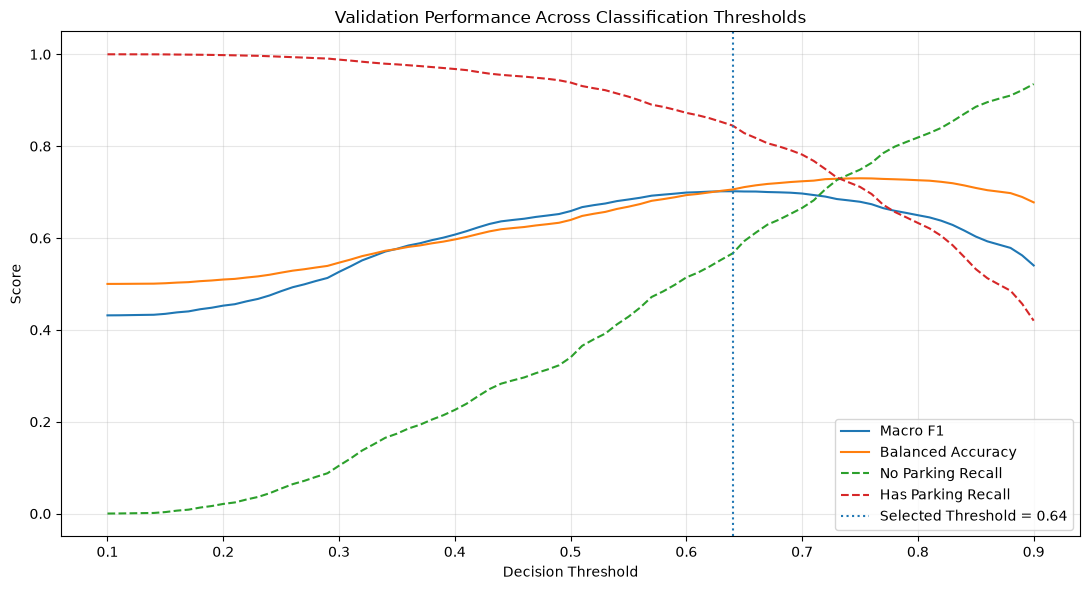

In [22]:
plt.figure(figsize=(11, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["macro_f1"],
    label="Macro F1"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["balanced_accuracy"],
    label="Balanced Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["no_parking_recall"],
    linestyle="--",
    label="No Parking Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["parking_recall"],
    linestyle="--",
    label="Has Parking Recall"
)

plt.axvline(
    best_threshold,
    linestyle=":",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Validation Performance Across Classification Thresholds")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
val_pred_tuned = (
    val_prob >= best_threshold
).astype(int)

print(
    "=== Tuned Validation Performance ==="
)

print(
    "Accuracy          :",
    round(
        accuracy_score(
            y_val,
            val_pred_tuned
        ),
        4
    )
)

print(
    "Macro F1          :",
    round(
        f1_score(
            y_val,
            val_pred_tuned,
            average="macro"
        ),
        4
    )
)

print(
    "Balanced Accuracy :",
    round(
        balanced_accuracy_score(
            y_val,
            val_pred_tuned
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val,
        val_pred_tuned,
        target_names=[
            "No Parking",
            "Has Parking"
        ]
    )
)

=== Tuned Validation Performance ===
Accuracy          : 0.7777
Macro F1          : 0.7019
Balanced Accuracy : 0.7057

Classification Report:

              precision    recall  f1-score   support

  No Parking       0.54      0.57      0.55     26342
 Has Parking       0.86      0.84      0.85     82881

    accuracy                           0.78    109223
   macro avg       0.70      0.71      0.70    109223
weighted avg       0.78      0.78      0.78    109223



## 6. Final Evaluation on the Test Set

After model training and threshold optimization were completed using only the
training and validation sets, the final model is evaluated once on the previously
untouched test set.

The decision threshold is fixed at the value selected on the validation data
(`0.64`) and is not modified based on test performance.

This provides an unbiased estimate of how well the model generalizes to unseen
labeled advertisements.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    classification_report
)

test_prob = catboost_model.predict_proba(X_test)[:, 1]

test_pred = (
    test_prob >= best_threshold
).astype(int)

print("=== Final Test Performance ===")

print(
    "Accuracy          :",
    round(accuracy_score(y_test, test_pred), 4)
)

print(
    "Precision         :",
    round(precision_score(y_test, test_pred), 4)
)

print(
    "Recall            :",
    round(recall_score(y_test, test_pred), 4)
)

print(
    "F1-score          :",
    round(f1_score(y_test, test_pred), 4)
)

print(
    "Macro F1          :",
    round(
        f1_score(
            y_test,
            test_pred,
            average="macro"
        ),
        4
    )
)

print(
    "Balanced Accuracy :",
    round(
        balanced_accuracy_score(
            y_test,
            test_pred
        ),
        4
    )
)

print(
    "ROC-AUC           :",
    round(
        roc_auc_score(
            y_test,
            test_prob
        ),
        4
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Parking",
            "Has Parking"
        ]
    )
)

=== Final Test Performance ===
Accuracy          : 0.7782
Precision         : 0.8597
Recall            : 0.8457
F1-score          : 0.8526
Macro F1          : 0.7022
Balanced Accuracy : 0.7058
ROC-AUC           : 0.8088

Classification Report:

              precision    recall  f1-score   support

  No Parking       0.54      0.57      0.55     26342
 Has Parking       0.86      0.85      0.85     82882

    accuracy                           0.78    109224
   macro avg       0.70      0.71      0.70    109224
weighted avg       0.78      0.78      0.78    109224



### 6.1 Confusion Matrix

The confusion matrix provides a direct view of the types of classification errors
made by the final model.

Unlike overall accuracy, it separately shows how successfully the model identifies
properties with and without parking.

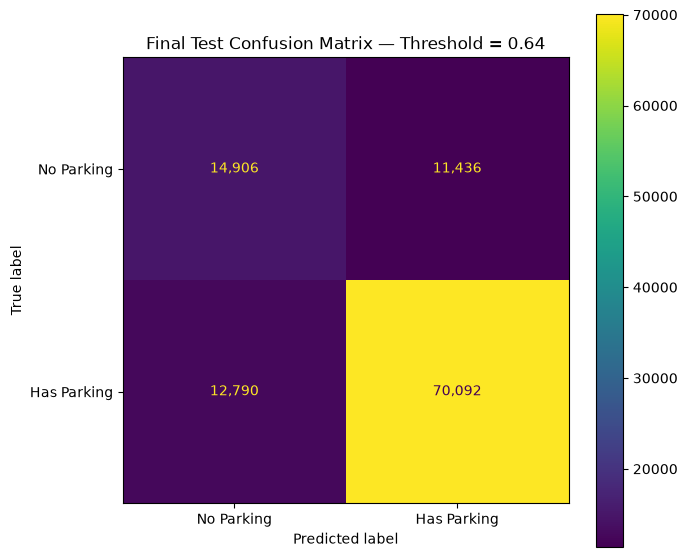

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Parking",
        "Has Parking"
    ]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format=","
)

plt.title(
    f"Final Test Confusion Matrix — Threshold = {best_threshold:.2f}"
)

plt.tight_layout()
plt.show()

## 7. Model Interpretation — Feature Importance

Beyond predictive performance, it is important to understand which available
features contributed most to the parking predictions.

CatBoost feature importance is therefore examined to provide an interpretable view
of the model's decision process.

In [26]:
feature_importance = pd.DataFrame({
    "feature": final_features,
    "importance": catboost_model.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
4,neighborhood_slug,42.609150
0,city_slug,30.857795
2,cat3_slug,14.990551
1,cat2_slug,8.426060
3,created_at_month,3.116445


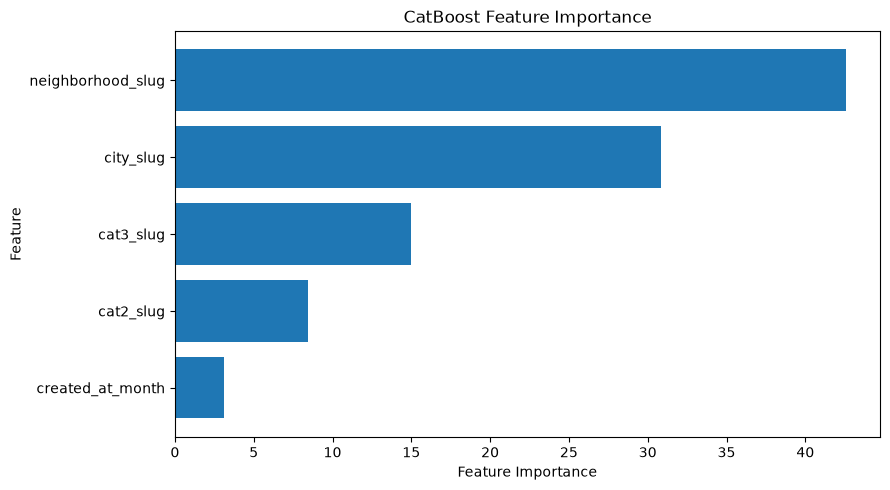

In [27]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.tight_layout()
plt.show()

## 8. Predicting Missing Parking Values

After validating the model on completely unseen test data, the final classifier is
applied to the small set of advertisements from relevant property categories where
parking information is missing.

The same preprocessing steps and the previously selected decision threshold
(`0.64`) are used.

These predictions are treated as model-based estimates rather than verified ground
truth.

In [28]:
prediction_df = unlabeled_parking.copy()

for col in final_features:
    prediction_df[col] = (
        prediction_df[col]
        .fillna("Missing")
        .astype(str)
    )

X_missing = prediction_df[final_features]

missing_prob = catboost_model.predict_proba(
    X_missing
)[:, 1]

missing_pred = (
    missing_prob >= best_threshold
).astype(int)

prediction_df["predicted_has_parking"] = missing_pred
prediction_df["parking_probability"] = missing_prob

print("Predictions completed:", len(prediction_df))

print("\nPredicted class counts:")
print(
    prediction_df["predicted_has_parking"]
    .value_counts()
    .rename(index={
        0: "No Parking",
        1: "Has Parking"
    })
)

print("\nPredicted percentages:")
print(
    prediction_df["predicted_has_parking"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(index={
        0: "No Parking",
        1: "Has Parking"
    })
)

Predictions completed: 115

Predicted class counts:
predicted_has_parking
No Parking     69
Has Parking    46
Name: count, dtype: int64

Predicted percentages:
predicted_has_parking
No Parking     60.0
Has Parking    40.0
Name: proportion, dtype: float64


### 8.1 Prediction Confidence

Because the predicted parking labels are not observed ground truth, probability
estimates are also examined.

Predictions close to 0.5 are less certain, while probabilities closer to 0 or 1
represent more confident model decisions.

In [29]:
prediction_df[
    [
        "city_slug",
        "cat3_slug",
        "neighborhood_slug",
        "predicted_has_parking",
        "parking_probability"
    ]
].sort_values(
    "parking_probability"
)

,city_slug,cat3_slug,neighborhood_slug,predicted_has_parking,parking_probability
761687,baghershahr,office-rent,Missing,0,0.095206
516539,mashhad,office-rent,bolvartoos,0,0.175446
404658,isfahan,office-rent,hashtbehesht,0,0.178172
281604,sabzevar,office-rent,Missing,0,0.184995
137958,zanjan,office-rent,Missing,0,0.185466
...,...,...,...,...,...
475630,nur,apartment-sell,Missing,1,0.949288
657876,karaj,house-villa-sell,azimieh,1,0.961729
277771,tehran,apartment-rent,aghdasieh,1,0.964663
961682,tehran,apartment-rent,niavaran,1,0.969701


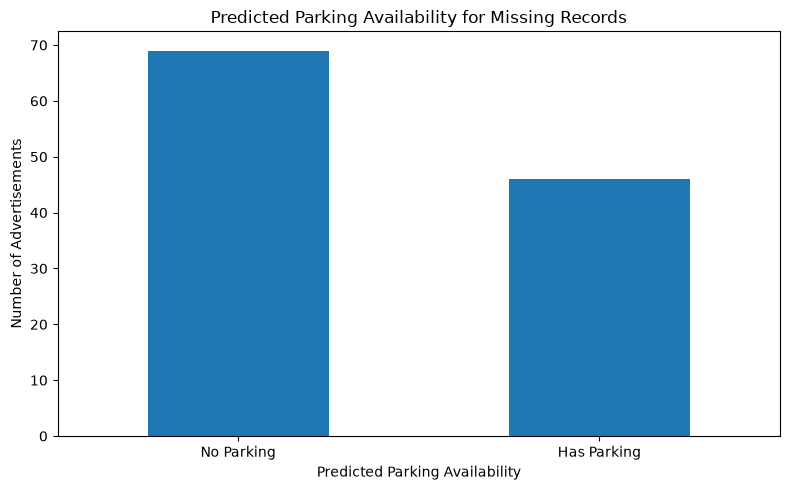

In [30]:
plt.figure(figsize=(8, 5))

prediction_df[
    "predicted_has_parking"
].value_counts().sort_index().plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["No Parking", "Has Parking"],
    rotation=0
)

plt.xlabel("Predicted Parking Availability")
plt.ylabel("Number of Advertisements")
plt.title("Predicted Parking Availability for Missing Records")

plt.tight_layout()
plt.show()

## 9. Final Conclusion

This bonus analysis formulated parking availability prediction as a supervised
binary classification problem.

Initial investigation showed that missing parking values were largely structural:
for many property categories, parking information was never collected. Therefore,
the modeling population was restricted to categories where parking is a meaningful
and routinely recorded attribute.

To avoid unrealistic model deployment, only features that were also available at
inference time were retained.

A CatBoost classifier was trained using categorical property context and evaluated
using separate training, validation, and test sets.

Because the target was imbalanced, the default decision threshold was optimized
using only the validation set. The final threshold of 0.64 improved the balance
between the two classes.

On the untouched test set, the final model achieved:

- Accuracy: 0.7782
- F1-score: 0.8526
- Macro F1-score: 0.7022
- Balanced Accuracy: 0.7058
- ROC-AUC: 0.8088

Geographic context was the most influential source of information, with neighborhood
and city being the two most important features.

Finally, the trained model was applied to the 115 relevant advertisements with
missing parking information:

- 69 (60%) were predicted as No Parking
- 46 (40%) were predicted as Has Parking

These final labels should be interpreted as model-based estimates rather than
verified ground truth.